## Домашнее задание
Чем лучше бустить? Тестируем алгоритмы бустинга в бою.

### Цель:
В этом домашнем задании вам предстоит провести детективную работу и узнать, какой же алгоритм бустинга работает лучше всего (конечно, применительно к конкретной задаче).

#### Описание/Пошаговая инструкция выполнения домашнего задания:
##### Часть 1. EDA

- Выберите любой интересующий вас датасет по классификации или регрессии (можно взять из репозитория https://archive.ics.uci.edu/ml/datasets.php, еще неплохие и востребованные на практике варианты - предсказание оттока пользователей https://www.kaggle.com/blastchar/telco-customer-churn или предсказание Customer Livetime Value (CLV или LTV) - https://www.kaggle.com/pankajjsh06/ibm-watson-marketing-customer-value-data
- По выбранному датасету проведите EDA, познакомьтесь с признаками, посмотрите зависимости и т.д.

##### Часть 2. Preprocessing & Feature Engineering

- Хотя цель этого задания - посмотреть на работу алгоритмов, тем не менее пропускать препроцессинг нельзя :)
- Так что переведите категориальные переменные в уникальные лейблы при помощи LabelEncoder, попробуйте добавить новые переменные и выкинуть лишние и, наконец, разбейте данные на train-test.

##### Часть 3. Who's the mightiest of them all?

- Постройте 4 варианта градиентного бустинга, используя значения гиперпараметров “из коробки”: реализация из sklearn, XGBoost, CatBoost, LightGBM
- Проверьте качество на отложенной выборке, кто пока лидирует?
- Теперь проведите настройку гиперпараметров моделей на кросс-валидации, можно настраивать только самые основные гиперпараметры - число итераций бустинга, max_features, subsample и т.д.
- Снова проверьте качество уже настроенных моделей. Кто в итоге победил?

### Критерии оценки:
- EDA для выбранного датасета - 1 балл.
- Preprocessing - 1 балл.
- Построение моделей из коробки и проверка качества - 4 балла.
- Настройка гиперпараметров моделей и проверка качества - 4 балла.

## Решение

В качестве материала для ДЗ выбран [датасет по предсказанию Customer Livetime Value (CLV или LTV)](https://www.kaggle.com/datasets/pankajjsh06/ibm-watson-marketing-customer-value-data), он предварительно сохранён в локальный файл [WA_Fn-UseC_-Marketing-Customer-Value-Analysis.csv](./WA_Fn-UseC_-Marketing-Customer-Value-Analysis.csv).

Мне не удалось найти описание назначения признаков, а описание самого датасета слабо затрагивает предметную область.\
Поэтому при работе с признаками исхожу из того, что IBM Watson - это [суперкомпьютер](https://ru.wikipedia.org/wiki/IBM_Watson) и целевой переменной [Customer Lifetime Value](https://ru.wikipedia.org/wiki/%D0%9F%D0%BE%D0%B6%D0%B8%D0%B7%D0%BD%D0%B5%D0%BD%D0%BD%D0%B0%D1%8F_%D1%86%D0%B5%D0%BD%D0%BD%D0%BE%D1%81%D1%82%D1%8C_%D0%BA%D0%BB%D0%B8%D0%B5%D0%BD%D1%82%D0%B0) датасет описывает доход с одного клиента за весь период пользования некой услугой доступа к вычислительным сервисам данного компьютера.

### 1. EDA

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [60]:
df = pd.read_csv('./WA_Fn-UseC_-Marketing-Customer-Value-Analysis.csv', sep=',')

In [61]:
# Не удалось вывести на печать весь набор признаков вызовами df.head() или print(df[:5])
# Поэтому вывожу двумя командами
PRINT_COLUMN_CHUNK_SIZE = 13

In [62]:
df.iloc[:5, :PRINT_COLUMN_CHUNK_SIZE]

,Customer,State,Customer Lifetime Value,Response,Coverage,Education,Effective To Date,EmploymentStatus,Gender,Income,Location Code,Marital Status,Monthly Premium Auto
0,BU79786,Washington,2763.519279,No,Basic,Bachelor,2/24/11,Employed,F,56274,Suburban,Married,69
1,QZ44356,Arizona,6979.535903,No,Extended,Bachelor,1/31/11,Unemployed,F,0,Suburban,Single,94
2,AI49188,Nevada,12887.431650,No,Premium,Bachelor,2/19/11,Employed,F,48767,Suburban,Married,108
3,WW63253,California,7645.861827,No,Basic,Bachelor,1/20/11,Unemployed,M,0,Suburban,Married,106
4,HB64268,Washington,2813.692575,No,Basic,Bachelor,2/3/11,Employed,M,43836,Rural,Single,73


In [63]:
df.iloc[:5, PRINT_COLUMN_CHUNK_SIZE:]

,Months Since Last Claim,Months Since Policy Inception,Number of Open Complaints,Number of Policies,Policy Type,Policy,Renew Offer Type,Sales Channel,Total Claim Amount,Vehicle Class,Vehicle Size
0,32,5,0,1,Corporate Auto,Corporate L3,Offer1,Agent,384.811147,Two-Door Car,Medsize
1,13,42,0,8,Personal Auto,Personal L3,Offer3,Agent,1131.464935,Four-Door Car,Medsize
2,18,38,0,2,Personal Auto,Personal L3,Offer1,Agent,566.472247,Two-Door Car,Medsize
3,18,65,0,7,Corporate Auto,Corporate L2,Offer1,Call Center,529.881344,SUV,Medsize
4,12,44,0,1,Personal Auto,Personal L1,Offer1,Agent,138.130879,Four-Door Car,Medsize


In [64]:
# Определение категорий признаков
target = ['Customer Lifetime Value']

drop_features = [
    'Customer', 
    'State',
    'Effective To Date',
    'Policy Type'
    ]

numeric_features = [
    'Months Since Last Claim',
    'Months Since Policy Inception',
    'Total Claim Amount',
    'Monthly Premium Auto',
    'Number of Open Complaints',
    'Number of Policies',
]

category_features = [
    'EmploymentStatus',
    'Sales Channel',
]

ordered_features = [
    'Coverage',
    'Education',
    'Renew Offer Type',
    'Policy',
    'Location Code',
    'Marital Status',
    'Vehicle Class',
    'Vehicle Size'
]

binary_features = [
    'Gender',
    'Response'
]

In [65]:
clean_df = df.drop(labels=drop_features, axis=1)

clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9134 entries, 0 to 9133
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Customer Lifetime Value        9134 non-null   float64
 1   Response                       9134 non-null   object 
 2   Coverage                       9134 non-null   object 
 3   Education                      9134 non-null   object 
 4   EmploymentStatus               9134 non-null   object 
 5   Gender                         9134 non-null   object 
 6   Income                         9134 non-null   int64  
 7   Location Code                  9134 non-null   object 
 8   Marital Status                 9134 non-null   object 
 9   Monthly Premium Auto           9134 non-null   int64  
 10  Months Since Last Claim        9134 non-null   int64  
 11  Months Since Policy Inception  9134 non-null   int64  
 12  Number of Open Complaints      9134 non-null   i

In [66]:
# Пропусков нет
clean_df.isnull().sum()

Customer Lifetime Value          0
Response                         0
Coverage                         0
Education                        0
EmploymentStatus                 0
Gender                           0
Income                           0
Location Code                    0
Marital Status                   0
Monthly Premium Auto             0
Months Since Last Claim          0
Months Since Policy Inception    0
Number of Open Complaints        0
Number of Policies               0
Policy                           0
Renew Offer Type                 0
Sales Channel                    0
Total Claim Amount               0
Vehicle Class                    0
Vehicle Size                     0
dtype: int64

In [67]:
for feature in ordered_features + category_features + binary_features:
    print(f'{feature}: \n\t{clean_df[feature].unique()}')

Coverage: 
	['Basic' 'Extended' 'Premium']
Education: 
	['Bachelor' 'College' 'Master' 'High School or Below' 'Doctor']
Renew Offer Type: 
	['Offer1' 'Offer3' 'Offer2' 'Offer4']
Policy: 
	['Corporate L3' 'Personal L3' 'Corporate L2' 'Personal L1' 'Special L2'
 'Corporate L1' 'Personal L2' 'Special L1' 'Special L3']
Location Code: 
	['Suburban' 'Rural' 'Urban']
Marital Status: 
	['Married' 'Single' 'Divorced']
Vehicle Class: 
	['Two-Door Car' 'Four-Door Car' 'SUV' 'Luxury SUV' 'Sports Car'
 'Luxury Car']
Vehicle Size: 
	['Medsize' 'Small' 'Large']
EmploymentStatus: 
	['Employed' 'Unemployed' 'Medical Leave' 'Disabled' 'Retired']
Sales Channel: 
	['Agent' 'Call Center' 'Web' 'Branch']
Gender: 
	['F' 'M']
Response: 
	['No' 'Yes']


In [68]:
# Преобразование нечисловых признаков
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

def get_encoded_feature_name(feature, category):
    return str(feature) + "_" + str(category)


ordinal_encoder = OrdinalEncoder(categories=[
        ['Basic', 'Extended', 'Premium'],
        ['High School or Below', 'College', 'Bachelor',  'Master', 'Doctor'],
        ['Offer1', 'Offer2', 'Offer3', 'Offer4'],
        ['Personal L1', 'Personal L2', 'Personal L3',  'Corporate L1', 'Corporate L2',  'Corporate L3', 'Special L1',   'Special L2',  'Special L3'],
        ['Rural', 'Suburban', 'Urban'],
        ['Single', 'Married', 'Divorced'],
        ['Two-Door Car', 'Four-Door Car', 'SUV', 'Luxury SUV', 'Sports Car','Luxury Car'],
        ['Small', 'Medsize', 'Large']
    ],
    dtype=np.int16
)

binary_encoder = OneHotEncoder(
    sparse_output=False, 
    drop='if_binary', 
    feature_name_combiner=get_encoded_feature_name,
    dtype=np.byte
)

category_encoder = OneHotEncoder(
    sparse_output=False, 
    feature_name_combiner=get_encoded_feature_name,
    dtype=np.byte
)

encoded_df = clean_df.copy()
encoded_df[binary_encoder.get_feature_names_out()] = binary_encoder.fit_transform(encoded_df[binary_features])
encoded_df[ordered_features] = ordinal_encoder.fit_transform(encoded_df[ordered_features])
encoded_df[category_encoder.get_feature_names_out()] = category_encoder.fit_transform(encoded_df[category_features])

encoded_df = encoded_df.drop(binary_features + category_features, axis=1)
encoded_df.head()

,Customer Lifetime Value,Coverage,Education,Income,Location Code,Marital Status,Monthly Premium Auto,Months Since Last Claim,Months Since Policy Inception,Number of Open Complaints,...,Response_Yes,EmploymentStatus_Disabled,EmploymentStatus_Employed,EmploymentStatus_Medical Leave,EmploymentStatus_Retired,EmploymentStatus_Unemployed,Sales Channel_Agent,Sales Channel_Branch,Sales Channel_Call Center,Sales Channel_Web
0,2763.519279,0,2,56274,1,1,69,32,5,0,...,0,0,1,0,0,0,1,0,0,0
1,6979.535903,1,2,0,1,0,94,13,42,0,...,0,0,0,0,0,1,1,0,0,0
2,12887.431650,2,2,48767,1,1,108,18,38,0,...,0,0,1,0,0,0,1,0,0,0
3,7645.861827,0,2,0,1,1,106,18,65,0,...,0,0,0,0,0,1,0,0,1,0
4,2813.692575,0,2,43836,0,0,73,12,44,0,...,0,0,1,0,0,0,1,0,0,0


array([[<Axes: title={'center': 'Customer Lifetime Value'}>,
        <Axes: title={'center': 'Coverage'}>,
        <Axes: title={'center': 'Education'}>,
        <Axes: title={'center': 'Income'}>],
       [<Axes: title={'center': 'Location Code'}>,
        <Axes: title={'center': 'Marital Status'}>,
        <Axes: title={'center': 'Monthly Premium Auto'}>,
        <Axes: title={'center': 'Months Since Last Claim'}>],
       [<Axes: title={'center': 'Months Since Policy Inception'}>,
        <Axes: title={'center': 'Number of Open Complaints'}>,
        <Axes: title={'center': 'Number of Policies'}>,
        <Axes: title={'center': 'Policy'}>],
       [<Axes: title={'center': 'Renew Offer Type'}>,
        <Axes: title={'center': 'Total Claim Amount'}>,
        <Axes: title={'center': 'Vehicle Class'}>,
        <Axes: title={'center': 'Vehicle Size'}>],
       [<Axes: title={'center': 'Gender_M'}>,
        <Axes: title={'center': 'Response_Yes'}>, <Axes: >, <Axes: >]],
      dtype=objec

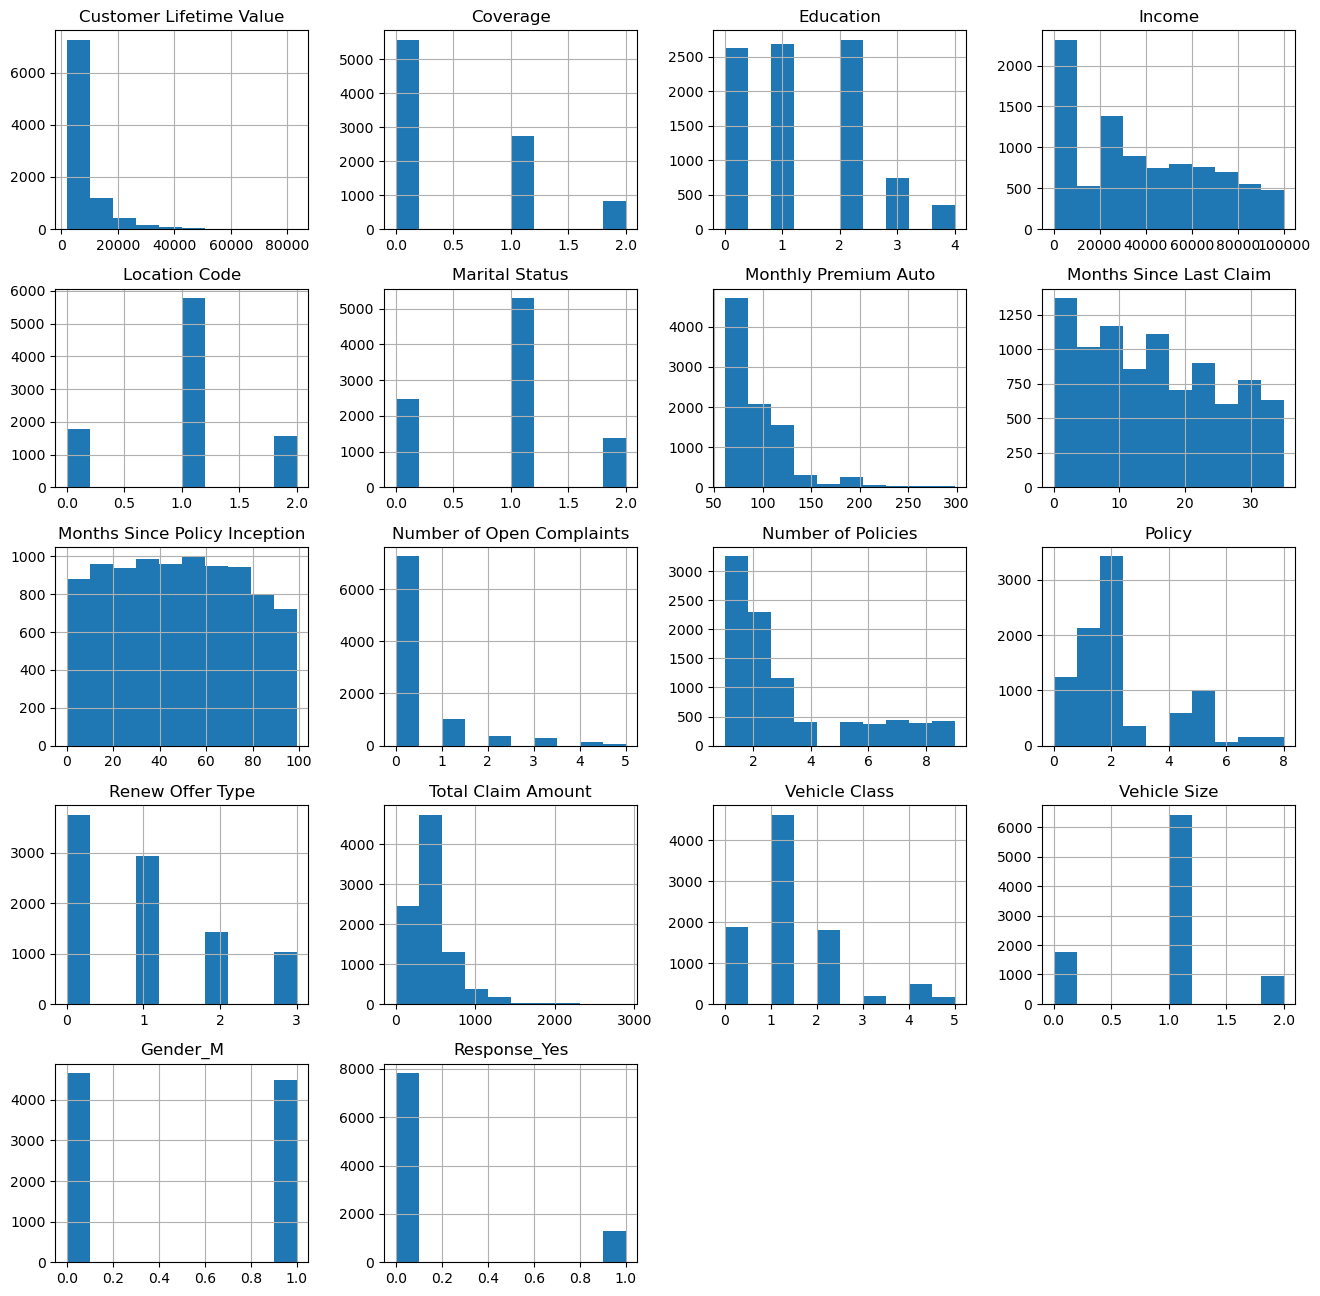

In [69]:
# Гистограммы распределения всех числовых значений за исключением категориальных признаков
synthetic_category_feature = [column for column in encoded_df.columns for category_feature in category_features if category_feature in column]

encoded_df.drop(synthetic_category_feature, axis=1).hist(figsize=(16, 16))

In [70]:
encoded_df.describe(include='all')

,Customer Lifetime Value,Coverage,Education,Income,Location Code,Marital Status,Monthly Premium Auto,Months Since Last Claim,Months Since Policy Inception,Number of Open Complaints,...,Response_Yes,EmploymentStatus_Disabled,EmploymentStatus_Employed,EmploymentStatus_Medical Leave,EmploymentStatus_Retired,EmploymentStatus_Unemployed,Sales Channel_Agent,Sales Channel_Branch,Sales Channel_Call Center,Sales Channel_Web
count,9134.000000,9134.000000,9134.000000,9134.000000,9134.000000,9134.000000,9134.000000,9134.000000,9134.000000,9134.000000,...,9134.000000,9134.00000,9134.000000,9134.000000,9134.000000,9134.000000,9134.000000,9134.000000,9134.000000,9134.000000
mean,8004.940475,0.480622,1.288373,37657.380009,0.979089,0.879790,93.219291,15.097000,48.064594,0.384388,...,0.143201,0.04434,0.623823,0.047296,0.030874,0.253668,0.380666,0.281038,0.193234,0.145062
std,6870.967608,0.655817,1.079984,30379.904734,0.605732,0.636838,34.407967,10.073257,27.905991,0.910384,...,0.350297,0.20586,0.484452,0.212282,0.172985,0.435133,0.485577,0.449531,0.394857,0.352183
min,1898.007675,0.000000,0.000000,0.000000,0.000000,0.000000,61.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3994.251794,0.000000,0.000000,0.000000,1.000000,0.000000,68.000000,6.000000,24.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5780.182197,0.000000,1.000000,33889.500000,1.000000,1.000000,83.000000,14.000000,48.000000,0.000000,...,0.000000,0.00000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8962.167041,1.000000,2.000000,62320.000000,1.000000,1.000000,109.000000,23.000000,71.000000,0.000000,...,0.000000,0.00000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000
max,83325.381190,2.000000,4.000000,99981.000000,2.000000,2.000000,298.000000,35.000000,99.000000,5.000000,...,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


<Axes: >

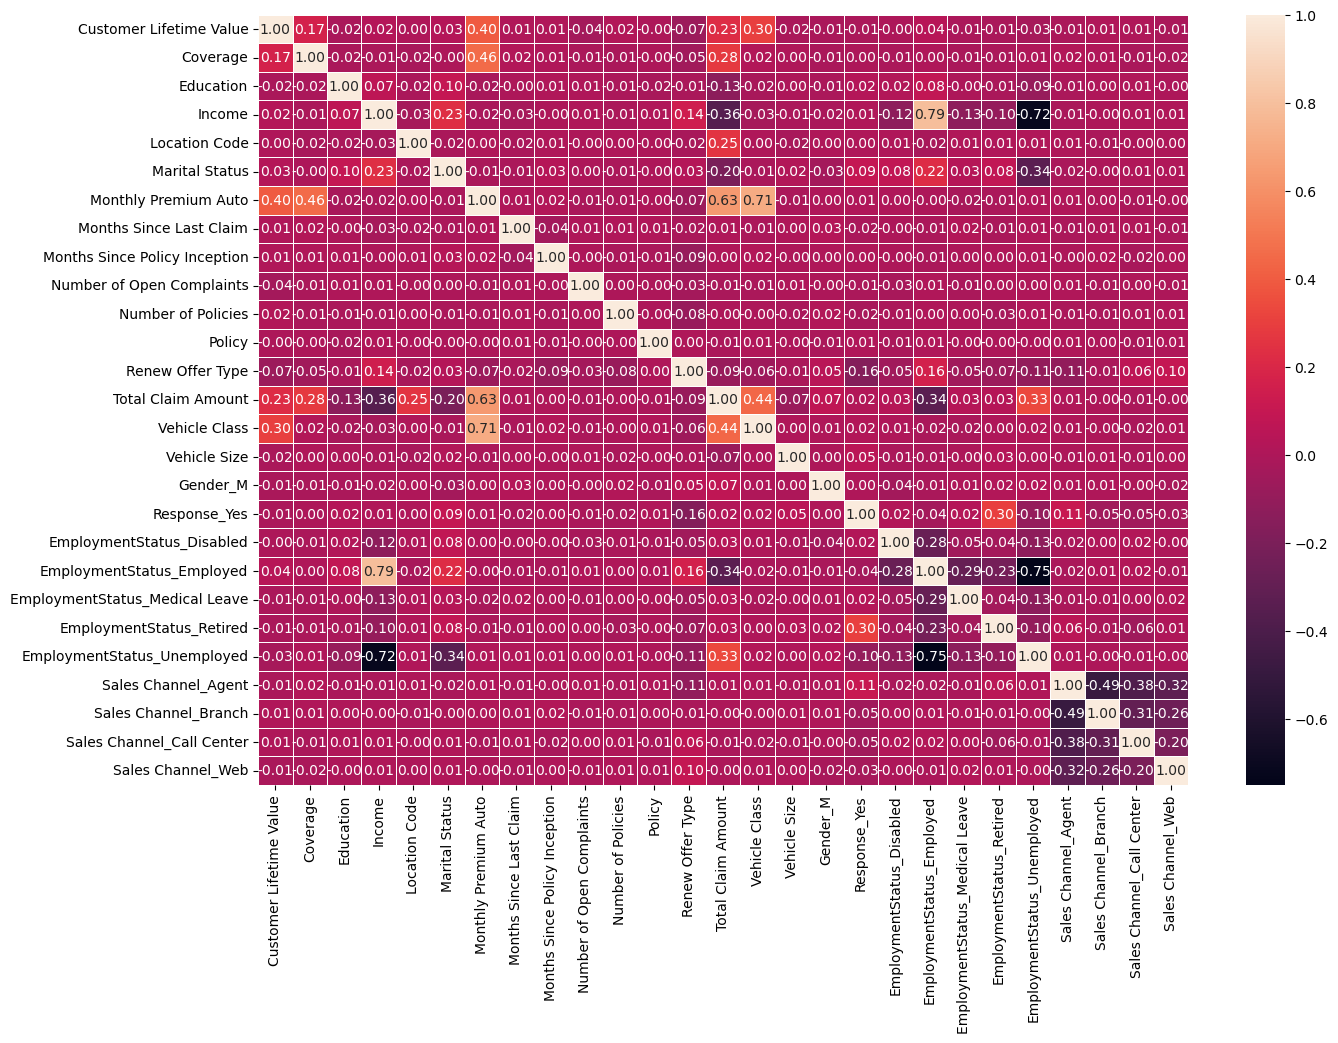

In [71]:
# Корреляция
plt.figure(figsize=(15, 10))
sns.heatmap(encoded_df.corr(), annot=True, cbar=True, linewidths=.5, fmt= '.2f')

##### Выводы по корреляции
- уровень дохода имеет сильную положительную связь для работающих и сильную отрицательную для безработных;
- величина ежемесячного пользования премиальными автомобилями имеет слабую положительную связь с целевой переменной, а также сильную положительную связь с величинами общей сумму претензий и классом автомобиля;
- целевая переменная не имеет выраженных связей с прочими величинами.

In [72]:
from sklearn.model_selection import train_test_split

In [73]:
X_train, X_test, y_train, y_test = train_test_split(
    encoded_df.drop(target, axis=1), encoded_df[target[0]], test_size=0.2, random_state=5
)

In [74]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((7307, 26), (1827, 26), (7307,), (1827,))

### 3. Построение моделей

In [75]:
from sklearn.metrics import root_mean_squared_error as RMSE
from sklearn.metrics import r2_score

from sklearn.ensemble import GradientBoostingRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

In [76]:
# Вспомогательные структуры
from enum import Enum

class Regressors(Enum):
    GradientBoosting = 0,
    CatBoost = 1
    LightGBM = 2
    XGBoost = 3


class QualityResult:
    basic_predict: list = []
    cv_predict: list = []
    tuned_predict: list = []


quality_results = {regressor: QualityResult() for regressor in Regressors }

#### Базовые модели

In [77]:
# Базовое непараметризованное построение модели
def basic_processing(regressor, X_train, y_train, X_test):
    regressor.fit(X_train, y_train)
    y_predict = regressor.predict(X_test)
    return y_predict

In [78]:
quality_results[Regressors.GradientBoosting].basic_predict = basic_processing(GradientBoostingRegressor(), X_train, y_train, X_test)

In [79]:
quality_results[Regressors.CatBoost].basic_predict = basic_processing(CatBoostRegressor(silent=True), X_train, y_train, X_test)

In [80]:
quality_results[Regressors.LightGBM].basic_predict = basic_processing(LGBMRegressor(verbosity=-1), X_train, y_train, X_test)

In [81]:
quality_results[Regressors.XGBoost].basic_predict = basic_processing(XGBRegressor(), X_train, y_train, X_test)

In [82]:
print('Basic RMSE:')
for result in quality_results.items():
    print(f'\t{result[0]}: {RMSE(y_test, result[1].basic_predict) if len(result[1].basic_predict) > 0 else None}')

print('Basic R2:')
for result in quality_results.items():
    print(f'\t{result[0]}: {r2_score(y_test, result[1].basic_predict) if len(result[1].basic_predict) > 0 else None}')

Basic RMSE:
	Regressors.GradientBoosting: 4101.626060227394
	Regressors.CatBoost: 3862.1705188378937
	Regressors.LightGBM: 3918.809304198646
	Regressors.XGBoost: 4104.372838897263
Basic R2:
	Regressors.GradientBoosting: 0.6801148580328764
	Regressors.CatBoost: 0.7163747904955982
	Regressors.LightGBM: 0.707995057880117
	Regressors.XGBoost: 0.6796862729398221


##### Выводы по базовым моделям
- лучший результат по метрике RMSE показала реализация CatBoost: 3862.17.

#### Модели с настройкой гиперпараметров через кросс-валидацию

In [83]:
from sklearn.model_selection import GridSearchCV

def cv_processing(regressor, param_grid, X_train, y_train, X_test):
    grid_search = GridSearchCV(regressor, param_grid, cv=5, scoring='neg_root_mean_squared_error', verbose=1)
    grid_search.fit(X_train, y_train)
    print(f'Best params: {grid_search.best_params_}\nBest train score: {abs(grid_search.best_score_)}')
    y_predict = grid_search.best_estimator_.predict(X_test)
    return y_predict

In [84]:
param_grid = {
        'learning_rate': np.arange(0.05, 0.2, 0.05),
        'n_estimators' : range(100, 400, 100),
        'max_depth': range(6, 10, 1)
}
quality_results[Regressors.GradientBoosting].cv_predict = cv_processing(GradientBoostingRegressor(), param_grid, X_train, y_train, X_test)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best params: {'learning_rate': np.float64(0.05), 'max_depth': 6, 'n_estimators': 100}
Best train score: 3810.706178493953


In [85]:
param_grid = {
        'learning_rate': np.arange(0.05, 0.2, 0.05),
        'iterations' : range(100, 400, 100),
        'depth': range(6, 10, 1)
}
quality_results[Regressors.CatBoost].cv_predict = cv_processing(CatBoostRegressor(silent=True), param_grid, X_train, y_train, X_test)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best params: {'depth': 8, 'iterations': 100, 'learning_rate': np.float64(0.1)}
Best train score: 3741.1974351093922


In [86]:
param_grid = {
        'learning_rate': np.arange(0.05, 0.2, 0.05),
        'n_estimators' : range(100, 400, 100),
        'max_depth': range(6, 10, 1)
}
quality_results[Regressors.LightGBM].cv_predict = cv_processing(LGBMRegressor(verbosity=-1), param_grid, X_train, y_train, X_test)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best params: {'learning_rate': np.float64(0.05), 'max_depth': 6, 'n_estimators': 100}
Best train score: 3768.3939417343777


In [87]:
param_grid = {
        'eta': np.arange(0.1, 0.4, 0.1),
        'n_estimators' : range(100, 300, 50),
        'max_depth': range(6, 10, 1)
}
quality_results[Regressors.XGBoost].cv_predict = cv_processing(XGBRegressor(), param_grid, X_train, y_train, X_test)

Fitting 5 folds for each of 64 candidates, totalling 320 fits
Best params: {'eta': np.float64(0.1), 'max_depth': 6, 'n_estimators': 100}
Best train score: 3784.061686146186


In [88]:
print('CV RMSE:')
for result in quality_results.items():
    print(f'\t{result[0]}: {RMSE(y_test, result[1].cv_predict) if len(result[1].cv_predict) > 0 else None}')

print('CV R2:')
for result in quality_results.items():
    print(f'\t{result[0]}: {r2_score(y_test, result[1].cv_predict) if len(result[1].cv_predict) > 0 else None}')

CV RMSE:
	Regressors.GradientBoosting: 4002.386397019966
	Regressors.CatBoost: 3968.192071105847
	Regressors.LightGBM: 3950.00256819265
	Regressors.XGBoost: 3992.6505855027053
CV R2:
	Regressors.GradientBoosting: 0.6954069648345619
	Regressors.CatBoost: 0.7005893039600295
	Regressors.LightGBM: 0.703327906109197
	Regressors.XGBoost: 0.6968870086596217


##### Выводы
- лучший результат по метрике RMSE показала реализация LightGBM: 3950, но это значение оказалось хуже чем лучшая базовая модель CatBoost;
- модели оказались хуже, так как наилучшая комбинация параметров подбиралась на тренировочном наборе, а качество проверялось уже на тестовом.

#### Модели с ручной настройкой гиперпараметров

In [89]:
quality_results[Regressors.GradientBoosting].tuned_predict = basic_processing(GradientBoostingRegressor(n_estimators=400, max_depth=8, subsample=0.9, min_samples_leaf=2, max_leaf_nodes=30, min_samples_split=4), X_train, y_train, X_test)

In [90]:
quality_results[Regressors.CatBoost].tuned_predict = basic_processing(CatBoostRegressor(silent=True, learning_rate=0.1, iterations=300, depth=9), X_train, y_train, X_test)

In [91]:
quality_results[Regressors.LightGBM].tuned_predict = basic_processing(LGBMRegressor(verbosity=-1, n_estimators=180, max_depth=8, num_leaves=25), X_train, y_train, X_test)

In [92]:
quality_results[Regressors.XGBoost].tuned_predict = basic_processing(XGBRegressor(n_estimators=300, eta=0.2, max_depth=10, subsample=0.9), X_train, y_train, X_test)

In [93]:
print('Manual RMSE:')
for result in quality_results.items():
    print(f'\t{result[0]}: {RMSE(y_test, result[1].tuned_predict) if len(result[1].tuned_predict) > 0 else None}')

print('Manual R2:')
for result in quality_results.items():
    print(f'\t{result[0]}: {r2_score(y_test, result[1].tuned_predict) if len(result[1].tuned_predict) > 0 else None}')

Manual RMSE:
	Regressors.GradientBoosting: 4069.263529279698
	Regressors.CatBoost: 3825.9043171863455
	Regressors.LightGBM: 3947.4042323906597
	Regressors.XGBoost: 4002.6291731834485
Manual R2:
	Regressors.GradientBoosting: 0.6851428405817594
	Regressors.CatBoost: 0.7216763252771616
	Regressors.LightGBM: 0.7037180831653189
	Regressors.XGBoost: 0.6953700117950866


##### Выводы
- лучший результат по метрике RMSE показала реализация CatBoost: 3825.9, значение немногим лучше базового 3862.17;
- базовая модель оказалась достаточно приемлемой и могла обойтись без донастройки.